In [1]:
import importlib.util
import sys
from pathlib import Path


custom_rqa_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "CustomRQA.py"

spec = importlib.util.spec_from_file_location("CustomRQA", str(custom_rqa_path))

CustomRQA = importlib.util.module_from_spec(spec)

spec.loader.exec_module(CustomRQA)

sys.modules["CustomRQA"] = CustomRQA


truncate_path = Path("/home/idies/workspace/RQA-and-mrDMD") / "truncate.py"

spec = importlib.util.spec_from_file_location("truncate", str(truncate_path))

truncate = importlib.util.module_from_spec(spec)

spec.loader.exec_module(truncate)

sys.modules["truncate"] = truncate


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
%pip install pydmd
%pip install statsmodels
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import CustomRQA as rqa
import truncate as tr

url = '/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/Data/time.npy'
time = np.load(url)

url = '/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/Data/sst_raw.npy'
sst_raw = np.load(url)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
print(time.shape)

(1590,)


In [4]:
start_time_snapshot = 0 
start_year = 1890
end_year   = 2023

tick_years = np.arange(start_year, end_year+1, 5)
tick_positions = (tick_years - start_year) * 12
window_size = int(0.1 * (time.shape[0]))

p=5


| Region                      | Latitude range | Longitude range | 
| --------------------------- | -------------- | --------------- | 
| **Western Pole (IOD‑west)** | 10°S – 10°N    | 50°E – 70°E     |            
| **Eastern Pole (IOD‑east)** | 10°S – 0°      | 90°E – 110°E    |


In [5]:
lats = np.linspace(89.5, -89.5, 180)
lons = np.linspace(0.5, 359.5, 360)

latmask_w = (lats >= -10) & (lats <= 10)        
lonmask_w = (lons >= 50) & (lons <= 70)         

mask_w = latmask_w[:,None] & lonmask_w[None,:]  
iw = np.where(mask_w)
latmask_e = (lats >= -10) & (lats <= 0)
lonmask_e = (lons >= 90) & (lons <= 110)

mask_e = latmask_e[:,None] & lonmask_e[None,:]
ie = np.where(mask_e)


In [6]:
western_box = sst_raw[:, mask_w]
eastern_box = sst_raw[:, mask_e]


In [7]:
%pip install cartopy

Note: you may need to restart the kernel to use updated packages.


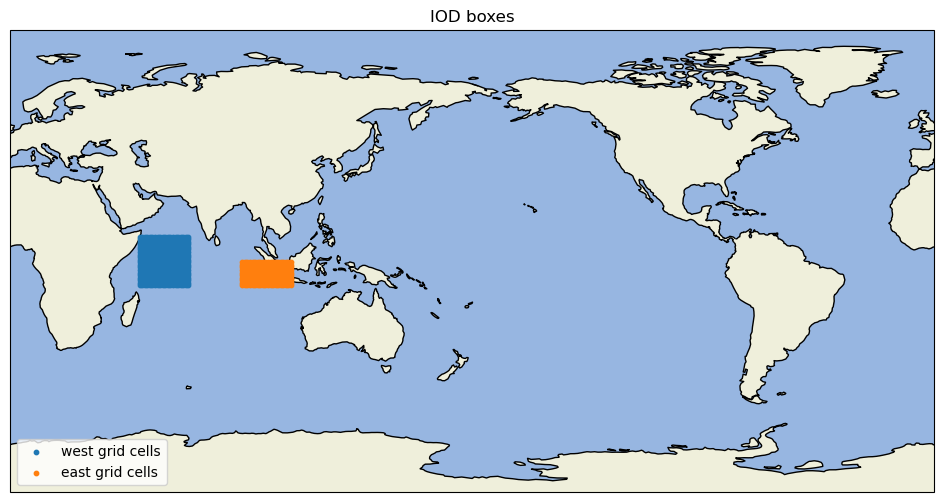

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature




lon2d = np.repeat(lons[None, :], lats.size, axis=0)   
lat2d = np.repeat(lats[:, None], lons.size, axis=1)   

w_lon = lon2d[mask_w]   
w_lat = lat2d[mask_w]
e_lon = lon2d[mask_e]
e_lat = lat2d[mask_e]


def lon_wrap(lon):
    return (lon + 180) % 360 - 180

fig, ax = plt.subplots(figsize=(12,6),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.coastlines(resolution='110m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.scatter(lon_wrap(w_lon), w_lat, s=10, transform=ccrs.PlateCarree(), label='west grid cells', zorder=3)
ax.scatter(lon_wrap(e_lon), e_lat, s=10, transform=ccrs.PlateCarree(), label='east grid cells', zorder=3)

ax.legend(loc='lower left')
ax.set_title("IOD boxes")
plt.show()


In [9]:
western_box= western_box.T
eastern_box = eastern_box.T

In [10]:
print(western_box.shape)
print(eastern_box.shape)

(400, 1590)
(200, 1590)


In [11]:
print(eastern_box[95])

[1.e+20 1.e+20 1.e+20 ... 1.e+20 1.e+20 1.e+20]


In [12]:
# IF its on land remove
new_rows = []
for r in eastern_box:
    row = np.array(r)
    if np.all(row == 1e20):
        continue

    new_rows.append(row)

eastern_box= np.array(new_rows)  

print(eastern_box.shape)

        
        

(176, 1590)


In [13]:
new_rows = []
for r in western_box:
    row = np.array(r)
    if np.all(row == 1e20):
        continue

    new_rows.append(row)

western_box= np.array(new_rows)  

print(western_box.shape)

(399, 1590)


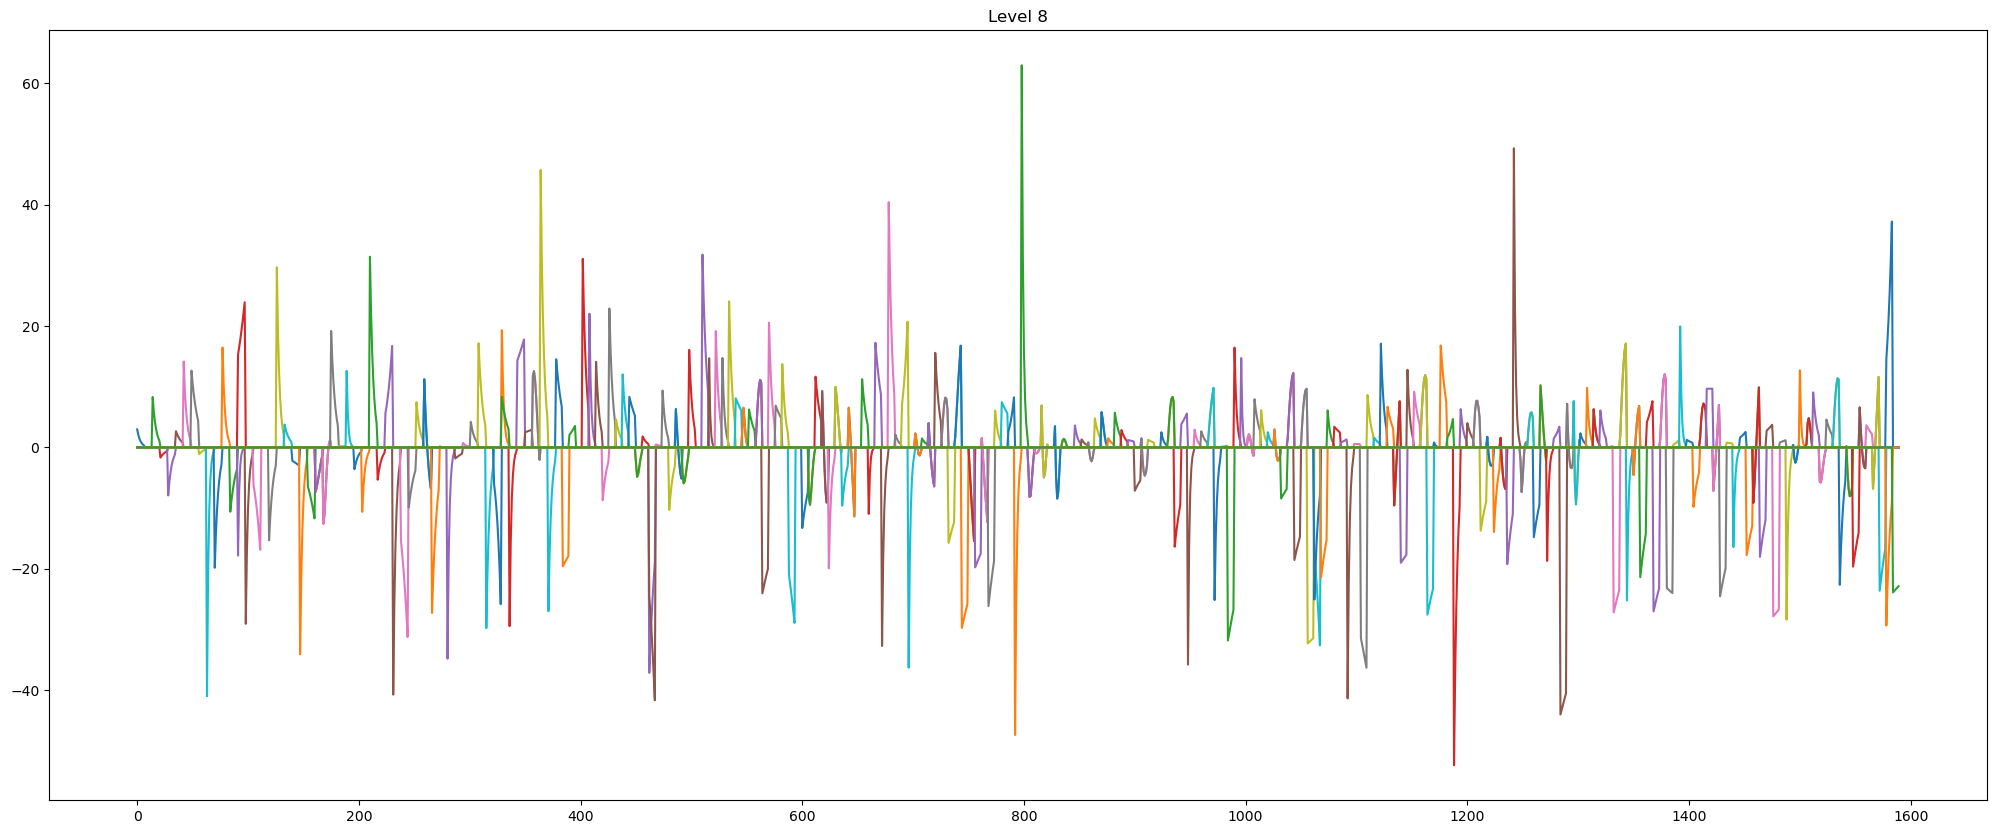

(1590, 254)


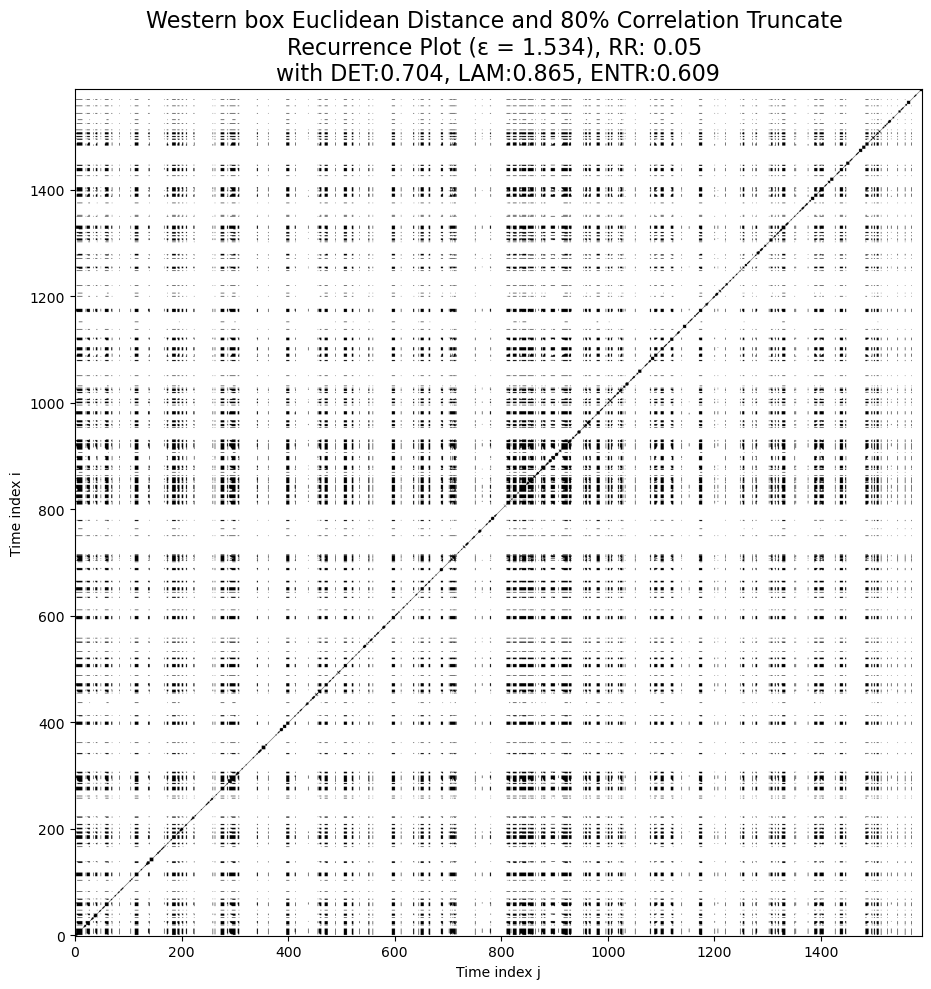

In [14]:
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
mrdmd.fit(western_box)

last_dynamics = mrdmd.partial_dynamics(level=l)
plt.figure(figsize=(25,10))
for i in range(last_dynamics.shape[0]):
    plt.plot(last_dynamics[i])
plt.title(f'Level {l}')
plt.show()
#last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold = 0.90)
all_vectors_new = df_dynamics.to_numpy()

print(all_vectors_new.shape)
all_vectors = (all_vectors_new.real)


final_west_box = all_vectors

metrics = rqa.RecurrencePlot(all_vectors, percent=p, metric ='euclidean', plot= True, globalEpsilon=True, Title = 'Western box Euclidean Distance and 80% Correlation Truncate',lines = False)

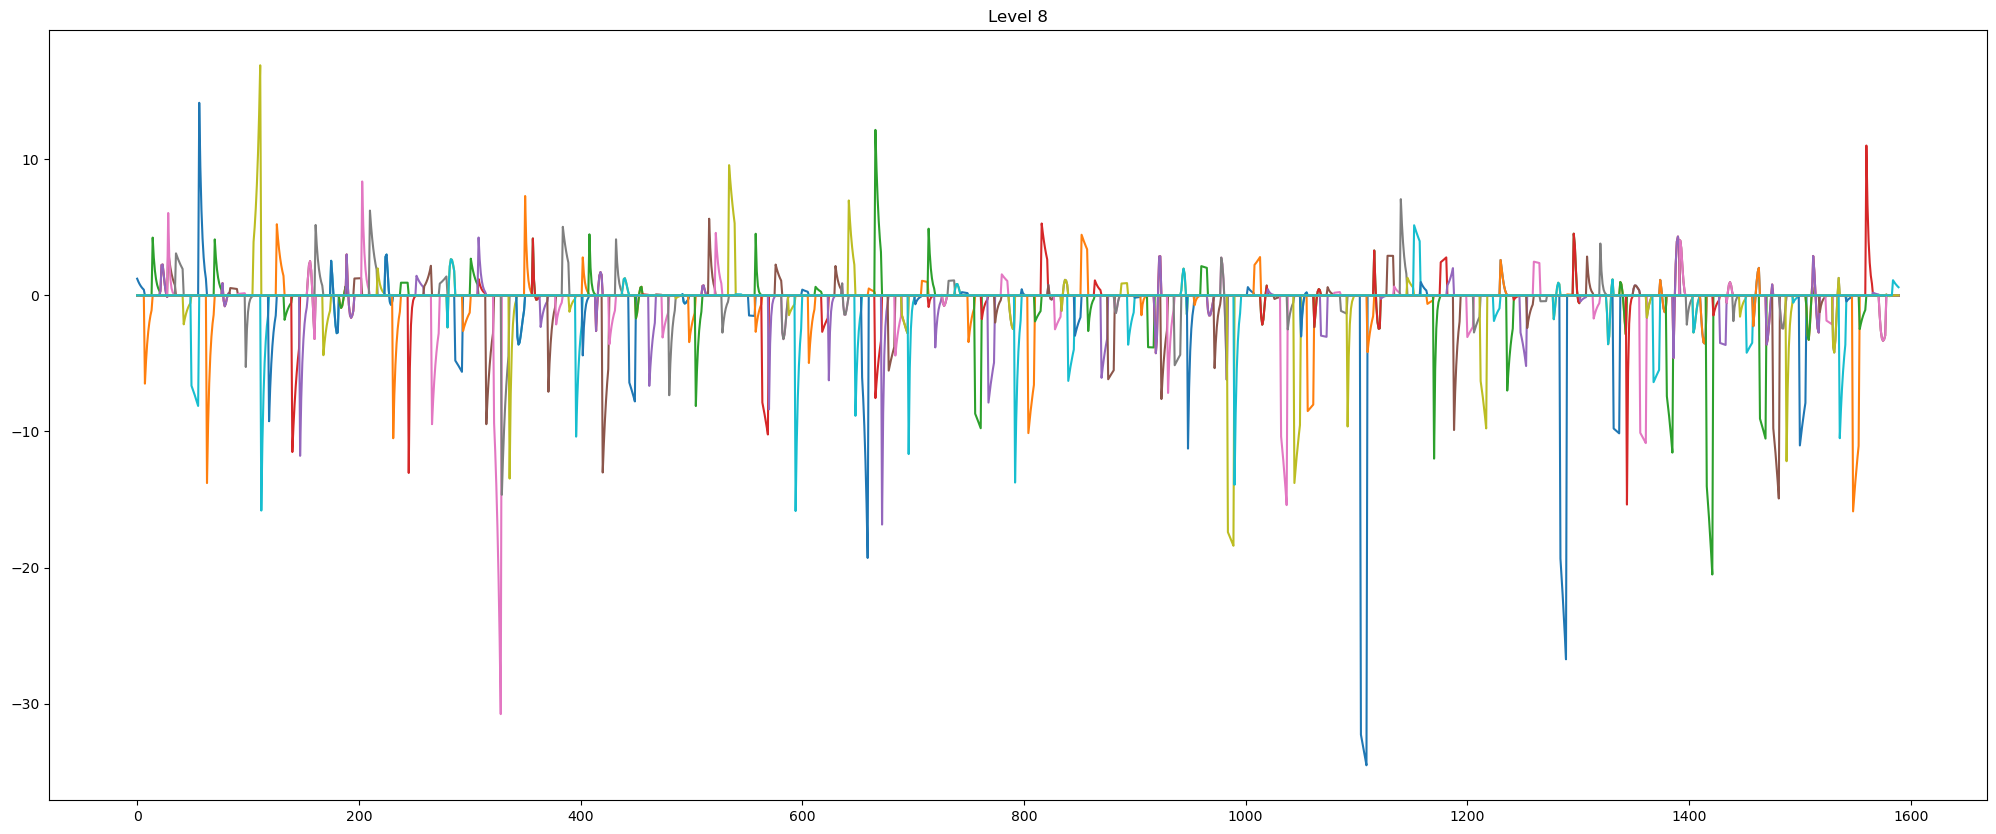

(1590, 253)


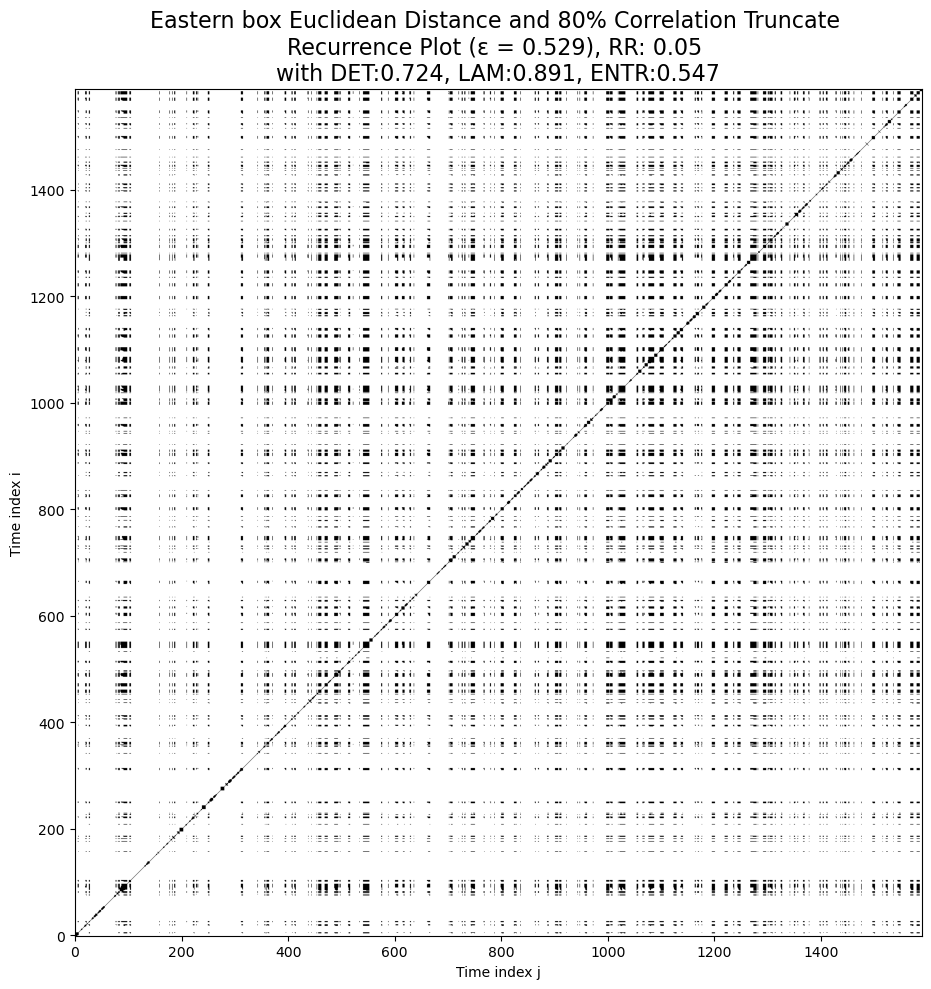

In [15]:
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
mrdmd.fit(eastern_box)

last_dynamics = mrdmd.partial_dynamics(level=l)
plt.figure(figsize=(25,10))
for i in range(last_dynamics.shape[0]):
    plt.plot(last_dynamics[i])
plt.title(f'Level {l}')
plt.show()
#last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold = 0.90)
all_vectors_new = df_dynamics.to_numpy()

print(all_vectors_new.shape)
all_vectors = (all_vectors_new.real)

final_west_box = all_vectors

metrics = rqa.RecurrencePlot(all_vectors, percent=p, metric ='euclidean', plot= True, globalEpsilon=True, Title = 'Eastern box Euclidean Distance and 80% Correlation Truncate',lines = False)

In [ ]:
from tqdm import tqdm
import time
X = western_box
print(X.shape)
total_time = X.shape[1]
window_size= .15 * total_time
one_side = window_size//2
times, det_ts, lam_ts, entr_ts = [], [], [], []
sub_dmd = DMD(svd_rank=0.75)
l=6
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
for t in tqdm(range(int(one_side), int(total_time - one_side))):
    time.sleep(0.1)
    block_X = X[:, int(t - one_side) : int(t + one_side) ]
    # print(block_X.shape)
    mrdmd.fit(block_X)
    last_dynamics = mrdmd.partial_dynamics(level=l)
    # last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
    df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
    all_vectors_new = df_dynamics.to_numpy()
    metrics,_ = rqa.RecurrencePlot(all_vectors_new, percent=p, globalEpsilon=True, plot=False)
    det_ts.append(metrics['DET'])
    lam_ts.append(metrics['LAM'])
    entr_ts.append(metrics['ENTR'])  
    times.append(t)
times = np.array(times)
DETS = det_ts
LAMS= lam_ts
ENTRS = entr_ts


In [ ]:
np.save('final_times_west.npy', times)
np.save('final_ENTRS_west.npy', ENTRS)
np.save('final_LAMS_west.npy', LAMS)
np.save('final_DETS_west.npy', DETS)

In [ ]:
print(len(DETS))

In [ ]:
x=X
real_times  = times
total_time  = western_box.shape[1]
time_axis   = np.arange(western_box.shape[1])


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
labels = ['(a)', '(b)', '(c)', '(d)']
c 
print(western_box.shape)
for j in range(western_box.shape[0]):
    axes[0].plot(time_axis, western_box[j], alpha=0.6)
axes[0].set_ylabel('Value', fontsize=14)
axes[0].set_title('All time series Western box', fontsize=12)
axes[0].text(1, 0.9, labels[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold')

axes[1].plot(real_times, DETS, label='DET')
axes[1].set_ylabel('DET', fontsize=14)
axes[1].set_title('Determinism vs. Time', fontsize=12)
axes[1].text(1, 0.9, labels[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold')

axes[2].plot(real_times, LAMS, label='LAM')
axes[2].set_ylabel('LAM', fontsize=14)
axes[2].set_title('Laminarity vs. Time', fontsize=12)
axes[2].text(1, 0.9, labels[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold')

axes[3].plot(real_times, ENTRS, label='ENTR')
axes[3].set_ylabel('ENTR', fontsize=14)
axes[3].set_title('Entropy vs. Time', fontsize=12)
axes[3].text(1, 0.9, labels[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold')

axes[3].set_xlabel('Year', fontsize=14)
axes[3].set_xlim(0, total_time)
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels([f'{yr}-01-01' for yr in tick_years], rotation=45, ha='right')

plt.show()
# Z score of data, normalize it 

In [ ]:
from scipy.signal import savgol_filter
DETS = savgol_filter(DETS, int(window_size//2), 2)
ENTRS = savgol_filter(ENTRS, int(window_size//2), 2)
LAMS = savgol_filter(LAMS, int(window_size//2), 2)

real_times  = times
total_time  = western_box.shape[1]
time_axis   = np.arange(western_box.shape[1])


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
labels = ['(a)', '(b)', '(c)', '(d)']

print(western_box.shape)
for j in range(western_box.shape[0]):
    axes[0].plot(time_axis, western_box[j], alpha=0.6)
axes[0].set_ylabel('Value', fontsize=14)
axes[0].set_title('All time series Western box', fontsize=12)
axes[0].text(1, 0.9, labels[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold')

axes[1].plot(real_times, DETS, label='DET')
axes[1].set_ylabel('DET', fontsize=14)
axes[1].set_title('Determinism vs. Time', fontsize=12)
axes[1].text(1, 0.9, labels[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold')

axes[2].plot(real_times, LAMS, label='LAM')
axes[2].set_ylabel('LAM', fontsize=14)
axes[2].set_title('Laminarity vs. Time', fontsize=12)
axes[2].text(1, 0.9, labels[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold')

axes[3].plot(real_times, ENTRS, label='ENTR')
axes[3].set_ylabel('ENTR', fontsize=14)
axes[3].set_title('Entropy vs. Time', fontsize=12)
axes[3].text(1, 0.9, labels[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold')

axes[3].set_xlabel('Year', fontsize=14)
axes[3].set_xlim(0, total_time)
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels([f'{yr}-01-01' for yr in tick_years], rotation=45, ha='right')

plt.show()

In [ ]:
times = np.load('/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/final_times.npy')

REAL_DETS = np.load('/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/final_DETS.npy')
REAL_LAMS = np.load('/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/final_LAMS.npy')
REAL_ENTRS = np.load('/home/idies/workspace/RQA-and-mrDMD/SeaSurfaceTemp/final_ENTRS.npy')


In [ ]:
import random
def get_metrics(DETS,LAMS,ENTRS,n):
    sampled_dets = []
    sampled_lams = []
    sampled_entr = []
    sampled_ratio = []
    N = DETS.shape[0] - 1
    for i in range(0,n):
        random_number = random.randint(0, N)
        det = DETS[random_number]
        lam = LAMS[random_number]
        entr = ENTRS[random_number]
        '''
                block = x[int(random_number-window_size//2): int(random_number+window_size//2)]
        metrics,_ = rqa.RecurrencePlot(block, percent=p, metric ='euclidean', globalEpsilon=True)
        det = metrics['DET']
        lam = metrics['LAM']
        entr = metrics['ENTR']
        '''
        sampled_dets.append(det)
        sampled_lams.append(lam)
        sampled_entr.append(entr)
    return sampled_dets, sampled_lams, sampled_entr
sampled_dets, sampled_lams, sampled_entr = get_metrics(DETS,LAMS,ENTRS,10000)

In [ ]:
import seaborn as sns
def bootstrap_ci(sampled_metric,n,alpha=0.05,plot=False, metric_name=''):
    if plot:
        plt.figure(figsize=(8, 5))
        sns.histplot(sampled_metric, bins=len(sampled_metric)//100, kde=True, stat="density", color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {metric_name} ")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.show()
    lo, hi = np.percentile(sampled_metric, [100*alpha/2, 100*(1-alpha/2)])
    print(lo,hi)
    return lo,hi
def plotting(metric, metric_name, lo,hi, percent):
    plt.figure(figsize=(12,8))
    plt.plot(real_times, metric)
    plt.ylabel(f'{metric_name}', fontsize=20)
    plt.title(f'{metric_name} vs. Time', fontsize=14)
    plt.xlim(0, total_time)
    plt.xlabel("Year", fontsize=20)
    plt.xlim(real_times.min(), real_times.max())
    plt.xticks(tick_positions,
               [f"{yr}-01-01" for yr in tick_years],
               rotation=45,
               ha='right')
    plt.fill_between(real_times, lo, hi, alpha=0.16, label=f'{100-percent}% sliding-window band', zorder=1, color='green')
    plt.tight_layout()
    plt.legend()
    plt.show()
print(real_times)
alpha=0.05
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(DETS, 'Determinism', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(LAMS, 'Laminairty', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)

In [ ]:
alpha=0.1
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(DETS, 'Determinism', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(LAMS, 'Laminairty', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)

In [ ]:
# Eastern Box

In [ ]:
sub_dmd = DMD(svd_rank=0.75)
l=8
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
mrdmd.fit(eastern_box.T)

last_dynamics = mrdmd.partial_dynamics(level=l)
plt.figure(figsize=(25,10))
for i in range(last_dynamics.shape[0]):
    plt.plot(last_dynamics[i])
plt.title(f'Level {l}')
plt.show()
#last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold = 0.90)
all_vectors_new = df_dynamics.to_numpy()

print(all_vectors_new.shape)
all_vectors = (all_vectors_new.real)
plt.figure(figsize=(25,10))
for i in range(all_vectors.shape[1]):
    plt.plot(all_vectors[:,i])
plt.title(f'Level {l}')
plt.show()

final_west_box = all_vectors

metrics = rqa.RecurrencePlot(all_vectors, percent=p, metric ='euclidean', plot= True, globalEpsilon=True, Title = 'Eastern box Euclidean Distance and 80% Correlation Truncate',lines = False)

In [ ]:
from tqdm import tqdm
import time
X = eastern_box
print(X.shape)
total_time = X.shape[1]
window_size= .15 * total_time
one_side = window_size//2
times, det_ts, lam_ts, entr_ts = [], [], [], []
sub_dmd = DMD(svd_rank=0.75)
l=6
mrdmd = MrDMD(sub_dmd, max_level=l, max_cycles=1)
for t in tqdm(range(int(one_side), int(total_time - one_side))):
    time.sleep(0.1)
    block_X = X[:, int(t - one_side) : int(t + one_side) ]
    mrdmd.fit(block_X)
    last_dynamics = mrdmd.partial_dynamics(level=l)
    # last_dynamics = StandardScaler().fit_transform(last_dynamics.real)
    df_dynamics = tr.correlation_truncate(last_dynamics.T, threshold =0.80)
    all_vectors_new = df_dynamics.to_numpy()
    metrics,_ = rqa.RecurrencePlot(all_vectors_new, percent=p, globalEpsilon=True, plot=False)
    det_ts.append(metrics['DET'])
    lam_ts.append(metrics['LAM'])
    entr_ts.append(metrics['ENTR'])  
    times.append(t)
times = np.array(times)
DETS = det_ts
LAMS= lam_ts
ENTRS = entr_ts

In [ ]:
np.save('final_times_east.npy', times)
np.save('final_ENTRS_east.npy', ENTRS)
np.save('final_LAMS_east.npy', LAMS)
np.save('final_DETS_east.npy', DETS)

In [ ]:
x=X
real_times  = times
total_time  = western_box.shape[1]
time_axis   = np.arange(western_box.shape[1])


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
labels = ['(a)', '(b)', '(c)', '(d)']

print(western_box.shape)
for j in range(western_box.shape[0]):
    axes[0].plot(time_axis, western_box[j], alpha=0.6)
axes[0].set_ylabel('Value', fontsize=14)
axes[0].set_title('All time series Western box', fontsize=12)
axes[0].text(1, 0.9, labels[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold')

axes[1].plot(real_times, DETS, label='DET')
axes[1].set_ylabel('DET', fontsize=14)
axes[1].set_title('Determinism vs. Time', fontsize=12)
axes[1].text(1, 0.9, labels[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold')

axes[2].plot(real_times, LAMS, label='LAM')
axes[2].set_ylabel('LAM', fontsize=14)
axes[2].set_title('Laminarity vs. Time', fontsize=12)
axes[2].text(1, 0.9, labels[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold')

axes[3].plot(real_times, ENTRS, label='ENTR')
axes[3].set_ylabel('ENTR', fontsize=14)
axes[3].set_title('Entropy vs. Time', fontsize=12)
axes[3].text(1, 0.9, labels[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold')

axes[3].set_xlabel('Year', fontsize=14)
axes[3].set_xlim(0, total_time)
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels([f'{yr}-01-01' for yr in tick_years], rotation=45, ha='right')

plt.show()

In [ ]:
from scipy.signal import savgol_filter
DETS = savgol_filter(DETS, int(window_size//2), 2)
ENTRS = savgol_filter(ENTRS, int(window_size//2), 2)
LAMS = savgol_filter(LAMS, int(window_size//2), 2)

real_times  = times
total_time  = western_box.shape[1]
time_axis   = np.arange(western_box.shape[1])


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)
labels = ['(a)', '(b)', '(c)', '(d)']

print(western_box.shape)
for j in range(western_box.shape[0]):
    axes[0].plot(time_axis, western_box[j], alpha=0.6)
axes[0].set_ylabel('Value', fontsize=14)
axes[0].set_title('All time series Western box', fontsize=12)
axes[0].text(1, 0.9, labels[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold')

axes[1].plot(real_times, DETS, label='DET')
axes[1].set_ylabel('DET', fontsize=14)
axes[1].set_title('Determinism vs. Time', fontsize=12)
axes[1].text(1, 0.9, labels[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold')

axes[2].plot(real_times, LAMS, label='LAM')
axes[2].set_ylabel('LAM', fontsize=14)
axes[2].set_title('Laminarity vs. Time', fontsize=12)
axes[2].text(1, 0.9, labels[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold')

axes[3].plot(real_times, ENTRS, label='ENTR')
axes[3].set_ylabel('ENTR', fontsize=14)
axes[3].set_title('Entropy vs. Time', fontsize=12)
axes[3].text(1, 0.9, labels[3], transform=axes[3].transAxes, fontsize=12, fontweight='bold')

axes[3].set_xlabel('Year', fontsize=14)
axes[3].set_xlim(0, total_time)
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels([f'{yr}-01-01' for yr in tick_years], rotation=45, ha='right')

plt.show()

In [ ]:
alpha=0.05
sampled_dets, sampled_lams, sampled_entr = get_metrics(DETS,LAMS,ENTRS,10000)
lo,hi = bootstrap_ci(sampled_dets,1,alpha=alpha,plot=True,metric_name='Dets')
plotting(DETS, 'Determinism', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_lams,1,alpha=alpha,plot=True,metric_name='Lams')
plotting(LAMS, 'Laminairty', lo,hi, alpha*100)
lo,hi = bootstrap_ci(sampled_entr,1,alpha=alpha,plot=True,metric_name='Entrs')
plotting(ENTRS, 'Entropy', lo,hi, alpha*100)